In [1]:
import math
import random
from matplotlib import pyplot as plt

/home/darija/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import import_ipynb 
from accuracy import calc_accuracy

In [3]:
import numpy as np
import pandas as pd
from copy import deepcopy

In [4]:
class Individual:
    def __init__(self, code):
        self.code = code  
        self.acc = None #-acc
        self.features_percentage = None

In [5]:
def dominates(individual1 :Individual, individual2 :Individual):
    return (individual1.acc >= individual2.acc and individual1.features_percentage <= individual2.features_percentage) and (individual1.acc > individual2.acc or individual1.features_percentage < individual2.features_percentage)

In [6]:
def nondominated_sort(population):
    n = len(population)
    dominated_by_p = [[] for _ in range(n)]

    dominators_count = [0 for i in range(n)]
    fronts = []

    for p in range(n):
        for q in range(n):
            if p == q: 
                continue
            if dominates(population[p],population[q]):
                dominated_by_p[p].append(q)
            elif dominates(population[q], population[p]):
                dominators_count[p] += 1
                
    current = [i for i,count in enumerate(dominators_count) if count == 0]
    rank = [None for _ in range(n)]
    level = 0
    while current:
        fronts.append(current)
        next_front = []
        for p in current:
            rank[p] = level
            for q in dominated_by_p[p]:
                dominators_count[q] -= 1 #izbacujemo q i onda se svim ostalim smanjuje dominators_count
                if dominators_count[q] == 0: #ako sad on postane dominantan dodamo ga
                    next_front.append(q)
        level += 1
        current = next_front
    return fronts, rank #frontovi i rang za svaku jedinku


In [7]:
def crowding_distance(front, population):

    if not front:
        return {}

    distance = {idx: 0.0 for idx in front}
    
    if len(front) < 3:
        for idx in front:
            distance[idx] = float('inf')
        return distance
    
    sorted_by_accuracy = sorted(front,key = lambda i : population[i].acc)
    distance[sorted_by_accuracy[0]] = float('inf') 
    distance[sorted_by_accuracy[-1]] = float('inf') 
    lowest = population[sorted_by_accuracy[0]].acc
    highest = population[sorted_by_accuracy[-1]].acc
    if lowest != highest: #ako su isti distance je svugde nula
        for k in range(1,len(sorted_by_accuracy)-1):
            prev_s = population[sorted_by_accuracy[k-1]].acc
            next_s = population[sorted_by_accuracy[k+1]].acc
            distance[sorted_by_accuracy[k]] += (next_s - prev_s) / (highest-lowest)


    sorted_by_features_percentage = sorted(front,key = lambda i : population[i].features_percentage)
    distance[sorted_by_features_percentage[0]] = float('inf') 
    distance[sorted_by_features_percentage[-1]] = float('inf') 
    lowest = population[sorted_by_features_percentage[0]].features_percentage
    highest = population[sorted_by_features_percentage[-1]].features_percentage
    if lowest != highest: #ako su isti distance je svugde nula
        for k in range(1,len(sorted_by_features_percentage)-1):
            prev_s = population[sorted_by_features_percentage[k-1]].features_percentage
            next_s = population[sorted_by_features_percentage[k+1]].features_percentage
            distance[sorted_by_features_percentage[k]] += (next_s - prev_s) / (highest-lowest)
    
    return distance

In [8]:
class NSGA2:
    def __init__(self, X_train, y_train, X_validation, y_validation, calc_accuracy_fn,
                 population_size=60, num_generations=40,feature_probability=0.1, mutation_probability=0.05):
        self.X_train = X_train
        self.y_train = y_train
        self.X_validation = X_validation
        self.y_validation = y_validation
        self.calc_acc = calc_accuracy_fn
        self.population_size = population_size
        self.num_generations = num_generations
        self.feature_probability = feature_probability
        self.mutation_probability = mutation_probability
  
    def initialize_population(self):
        n = self.X_train.shape[1]
        population = []
        for _ in range(self.population_size):
            code = (np.random.rand(n) < self.feature_probability)
            population.append(Individual(code))
        return population

    def eval(self, ind: Individual):
        #todo cuvati da se ne racunaju opet svaki put
        acc = self.calc_acc(ind.code, self.X_train, self.y_train, self.X_validation, self.y_validation)
        selected_features = int(ind.code.sum())
        all_features = self.X_train.shape[1]
        #accuracy_f =  acc
        features_f = selected_features / float(all_features)
        ind.acc = acc
        ind.features_percentage = features_f
        return [acc,features_f] #mislim da mi ovo ne treba

    def tournament_selection(self, population, ranks, distances):
        a = random.randrange(len(population))
        b = random.randrange(len(population))
        rank_a = ranks[a] 
        rank_b = ranks[b] 

        if rank_a is None:
            rank_a = float('inf')
        if rank_b is None:
            rank_b = float('inf')
        
        if rank_a < rank_b:
            return a
        if rank_b < rank_a:
            return b
        
        if rank_a == float('inf'):
            if random.random() < 0.5:
                return a
            return b
            
        dist_a = distances[rank_a].get(a, 0.0)
        dist_b = distances[rank_a].get(b, 0.0)
        
        if dist_a > dist_b:
            return a
        return b
        
    def crossover(self, p1: Individual, p2: Individual):
        n = len(p1.code)
        bpoint = random.randrange(1, n)
        c1 = np.concatenate([p1.code[:bpoint], p2.code[bpoint:]])
        c2 = np.concatenate([p2.code[:bpoint], p1.code[bpoint:]])
        return Individual(c1), Individual(c2)

    def mutate(self, ind: Individual):
        for i in range(len(ind.code)):
            if random.random() < self.mutation_probability:
                ind.code[i] = not ind.code[i]
        return ind

    def plot_fronts(population, fronts):
        plt.figure(figsize=(8,6))

        colors = ['red', 'blue', 'yellow', 'pink', 'purple']
        labels = [f'Front {i+1}' for i in range(len(fronts))]

        for idx, front in enumerate(fronts):
            accs = [population[i].acc for i in front]
            features_percentages = [population[i].features_percentage for i in front]
            color = colors[idx]
            label = labels[idx]
            plt.scatter(features_percentages, accs, c=[color], label=label)

        plt.xlabel('Features percentage')
        plt.ylabel('Accuracy')
        plt.title('NSGA-II pareto fronts')
        plt.legend()
        plt.grid(True)
        plt.show()

    def run(self):
        population = self.initialize_population()
        for ind in population:
            self.eval(ind)

        for generation in range(self.num_generations):
            fronts, ranks = nondominated_sort(population)
            distances = [crowding_distance(f,population) for f in fronts]
            #print(distances)
            #break;
            children = []
            
            while len(children) < self.population_size:
                i1 = self.tournament_selection(population, ranks, distances)
                i2 = self.tournament_selection(population, ranks, distances)
                p1 = deepcopy(population[i1]) #mozda ne mora 
                p2 = deepcopy(population[i2])
                c1, c2 = self.crossover(p1, p2)
                children.append(self.mutate(c1))
                if len(children) < self.population_size:
                    children.append(self.mutate(c2))

            for child in children:
                self.eval(child)

            combined = population + children
            fronts, ranks = nondominated_sort(combined)
            new_population = []
            for front in fronts:
                if len(new_population) + len(front) <= self.population_size:
                    new_population.extend([combined[i] for i in front])
                else:
                    dist = crowding_distance(front, combined)
                    sorted_by_distance = sorted(front,key=lambda i : dist.get(i,0.0),reverse=True)
                    remaining_slots = self.population_size - len(new_population)
                    new_population.extend([combined[i] for i in sorted_by_distance[:remaining_slots]])
                    break
            population = new_population

        fronts, ranks = nondominated_sort(population)
        pareto = [population[i] for i in fronts[0]]
        
        for individual in pareto:
            print(str(individual.acc) + " " + str(individual.features_percentage))
        #plot_pareto_front(population,fronts[0])
        NSGA2.plot_fronts(population,fronts[0:5])
        return pareto

In [9]:
X_train = pd.read_csv('data/X_train.csv')
X_validation  = pd.read_csv('data/X_validation.csv')

y_train = pd.read_csv('data/y_train.csv')
y_validation  = pd.read_csv('data/y_validation.csv')

1.0 0.04614953008837144
0.9166666666666666 0.04432599242530509


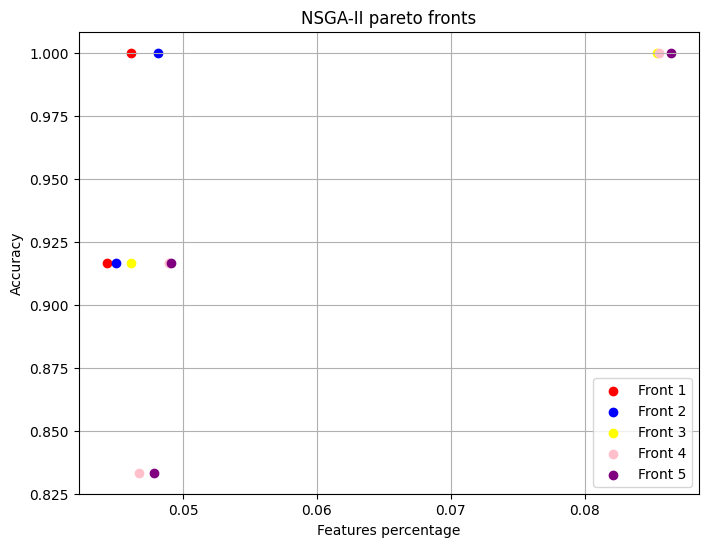

In [17]:
nsga = NSGA2(X_train, y_train, X_validation, y_validation, calc_accuracy_fn=calc_accuracy,
                   population_size=30, num_generations=20, feature_probability=0.05)

pareto = nsga.run()


In [18]:
X_train_madelon = pd.read_csv("../madelon/X_train.csv")
X_validation_madelon = pd.read_csv("../madelon/X_validation.csv")

y_train_madelon = pd.read_csv('../madelon/y_train.csv')
y_validation_madelon  = pd.read_csv('../madelon/y_validation.csv')

0.61875 0.022
0.565625 0.014
0.484375 0.006
0.503125 0.01
0.671875 0.068
0.68125 0.094
0.684375 0.15


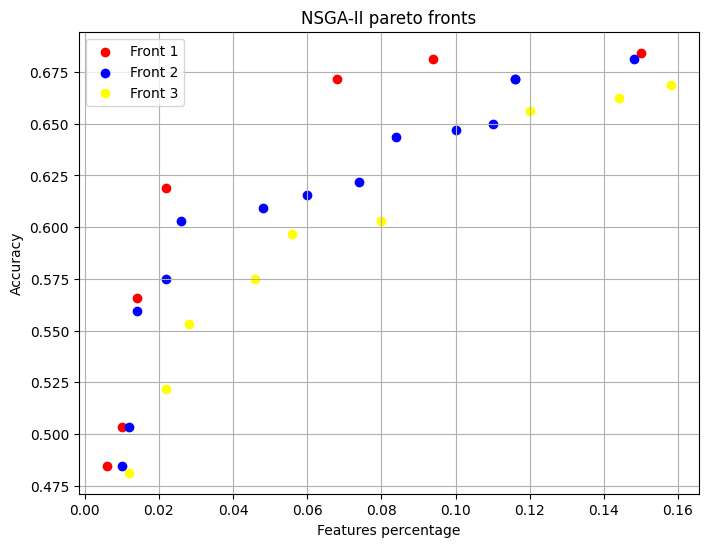

In [24]:
nsga = NSGA2(X_train_madelon, y_train_madelon, X_validation_madelon, y_validation_madelon, calc_accuracy_fn=calc_accuracy,
                   population_size=30, num_generations=20, feature_probability=0.02)

pareto = nsga.run()


In [25]:
code = pareto[-1].code

In [26]:
X_test_madelon = pd.read_csv("../madelon/X_test.csv")
y_test_madelon = pd.read_csv("../madelon/y_test.csv")

In [28]:
acc = calc_accuracy(code,X_train_madelon, y_train_madelon,X_test_madelon,y_test_madelon)
acc

0.65

In [29]:
#todo primeni simulirano kaljenje na prvi front